# 🌦️ Cambodia Weather Forecast Analysis
### Fundamentals of Data Science Project
Cambodia Academy of Digital Technology (Group 4)

This notebook analyzes weather trends in Cambodia using government open data to explore climate patterns and forecasting insights.

In [35]:
# import Library
import pandas as pd
import requests
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import time

# plot style for cleaner visuals
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## Fetch Weather Data
Collect real-time weather data from Cambodia government API for analysis of temperature, humidity, and climate trends.

In [36]:
# Provinces and coordinates
locations = [
    ("Phnom Penh", 11.55, 104.91),
    ("Siem Reap", 13.36, 103.85),
    ("Battambang", 13.10, 103.20),
    ("Sihanoukville", 10.62, 103.52),
    ("Mondulkiri", 12.45, 107.20),
]

# Request configuration
url = "https://archive-api.open-meteo.com/v1/archive"
start_date = "2015-01-01"
end_date = (datetime.now() - timedelta(days=2)).strftime("%Y-%m-%d") # safe API

all_data = [] 

for province, lat, lon in locations:
    print(f"Fetching data for {province}...")

    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,
        "end_date": end_date,
        "daily": [
            "temperature_2m_max",
            "temperature_2m_min",
            "precipitation_sum",
            "wind_speed_10m_max",
        ],
        "timezone": "Asia/Bangkok",
    }

    try:
        response = requests.get(url, params=params, timeout=30)
        response.raise_for_status()
        payload = response.json()

        province_df = pd.DataFrame(payload["daily"])
        province_df["province"] = province
        province_df["lat"] = lat
        province_df["lon"] = lon
        all_data.append(province_df)

        time.sleep(0.8)  # Respectful delay between requests

    except Exception as err:
        print(f"Skipped {province} due to error: {err}")

if all_data:
    final_df = pd.concat(all_data, ignore_index=True)
    final_df = final_df.rename(
        columns={
            "time": "date",
            "temperature_2m_max": "temp_max",
            "temperature_2m_min": "temp_min",
            "precipitation_sum": "rain",
            "wind_speed_10m_max": "wind_speed",
        }
    )

    output_path = "../data/cambodia_weather.csv"
    final_df.to_csv(output_path, index=False)
    print(f"Saved {len(final_df):,} rows to {output_path}")
else:
    final_df = pd.DataFrame()
    print("No data retrieved from API.")

Fetching data for Phnom Penh...
Fetching data for Siem Reap...
Fetching data for Battambang...
Fetching data for Sihanoukville...
Fetching data for Mondulkiri...
Saved 20,540 rows to ../data/cambodia_weather.csv


### 2. Exploratory Data Analysis (Step-by-Step)
This section is organized for clear understanding of the dataset before deeper analysis:
1. Load the dataset for EDA.
2. Check total rows and columns.
3. Inspect column names and data types.
4. Validate missing values and date coverage.
5. Continue with statistics and visualization.

In [47]:
# Load dataset
try:
    df = pd.read_csv("../data/cambodia_weather.csv")
    print("Dataset loaded from ../data/cambodia_weather.csv")
except FileNotFoundError:
    df = final_df.copy()
    print("CSV not found, using in-memory final_df instead")

# rows and columns
rows, cols = df.shape
print(f"Total rows: {rows:,}")
print(f"Total columns: {cols}")

df.head()

Dataset loaded from ../data/cambodia_weather.csv
Total rows: 20,540
Total columns: 8


,date,temp_max,temp_min,rain,wind_speed,province,lat,lon
0,2015-01-01,30.1,20.5,0.0,20.0,Phnom Penh,11.55,104.91
1,2015-01-02,30.0,19.9,0.0,18.7,Phnom Penh,11.55,104.91
2,2015-01-03,31.2,22.6,0.0,16.9,Phnom Penh,11.55,104.91
3,2015-01-04,31.5,22.2,0.0,9.4,Phnom Penh,11.55,104.91
4,2015-01-05,32.2,23.6,0.0,9.7,Phnom Penh,11.55,104.91


### Step 3. Inspect Columns and Data Types
Now we check what each column represents and confirm data types before cleaning.

In [40]:
# Column list and data types
print("Columns in dataset:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

# Convert and prepare key fields for analysis
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date", "temp_max", "temp_min", "rain", "wind_speed", "province"])
df = df.drop_duplicates().sort_values(["province", "date"]).reset_index(drop=True)
df["temp_avg"] = (df["temp_max"] + df["temp_min"]) / 2
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

print(f"\nShape after preparation: {df.shape}")

Columns in dataset:
1. date
2. temp_max
3. temp_min
4. rain
5. wind_speed
6. province
7. lat
8. lon

Data types:


,dtype
date,object
temp_max,float64
temp_min,float64
rain,float64
wind_speed,float64
province,object
lat,float64
lon,float64



Shape after preparation: (20540, 11)


### Step 4. Data Quality Check
After type conversion and cleaning, verify missing values and date coverage.

In [41]:
# Missing-value report
print("Missing values by column:")
display(df.isna().sum().sort_values(ascending=False))

# Date coverage check
print("\nDate coverage:")
print(f"Start date: {df['date'].min().date()}")
print(f"End date:   {df['date'].max().date()}")

# Province-level descriptive statistics
summary_stats = (
    df.groupby("province")[["temp_max", "temp_min", "temp_avg", "rain", "wind_speed"]]
    .agg(["mean", "median", "std"])
    .round(2)
)
summary_stats

Missing values by column:


date          0
temp_max      0
temp_min      0
rain          0
wind_speed    0
province      0
lat           0
lon           0
temp_avg      0
year          0
month         0
dtype: int64


Date coverage:
Start date: 2015-01-01
End date:   2026-03-31


temp_max              temp_min              temp_avg         \
                  mean median   std     mean median   std     mean median   
province                                                                    
Battambang       32.75  32.55  2.83    24.25   24.6  2.15    28.50  28.50   
Mondulkiri       27.42  27.10  2.53    19.92   20.5  1.88    23.67  23.70   
Phnom Penh       32.18  32.00  2.18    24.71   24.9  1.47    28.44  28.35   
Siem Reap        31.95  31.80  2.35    24.12   24.5  2.18    28.04  28.00   
Sihanoukville    29.85  29.80  1.49    24.94   24.9  1.12    27.40  27.40   

                     rain               wind_speed               
                std  mean median    std       mean median   std  
province                                                         
Battambang     2.26  3.73    1.0   6.38      14.77   14.3  4.34  
Mondulkiri     1.75  4.67    1.5   8.04      19.14   18.1  7.08  
Phnom Penh     1.61  4.64    1.4   7.22      14.81   14.5  4.03  
Siem Reap      2.03  4.60    1.1   7.47      13.38   13.0  3.72  
Sihanoukville  1.05  8.55    4.2  11.15      14.17   13.6  4.44

### Step 4. Visual Analysis
We use visual EDA to understand variability and trends:
- Temperature spread across provinces.
- Monthly rainfall pattern.
- Yearly temperature trend by province.

C:\Users\ROG\AppData\Local\Temp\ipykernel_27140\3958132997.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="province", y="temp_avg", palette="Set2")


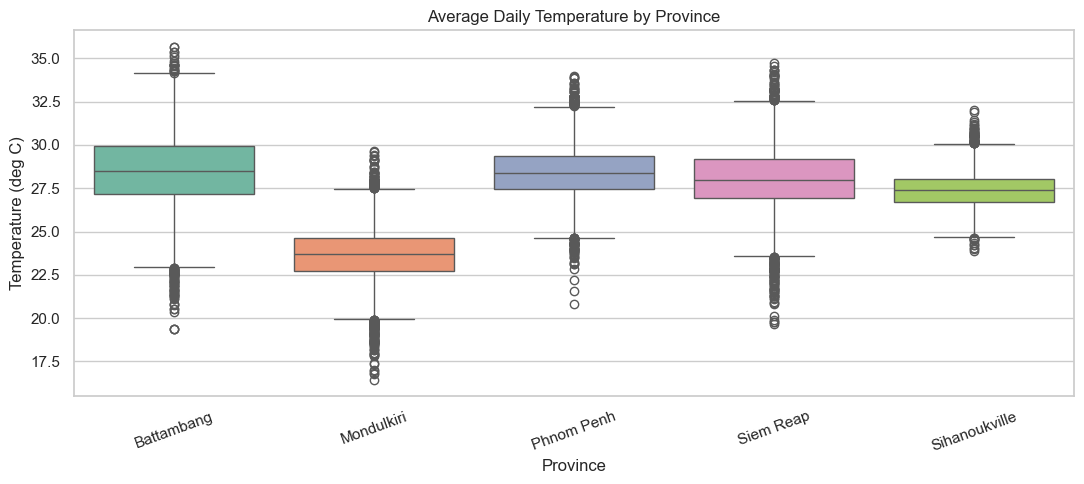

In [46]:
# Temperature distribution by province
plt.figure(figsize=(11, 5))
sns.boxplot(data=df, x="province", y="temp_avg", palette="Set2")
plt.title("Average Daily Temperature by Province")
plt.xlabel("Province")
plt.ylabel("Temperature (deg C)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Step 5. Temporal Trends
We now evaluate weather behavior over time to reveal seasonal and long-term signals useful for forecasting.

#### 5.1 Monthly Rainfall Trend (All Provinces Combined)

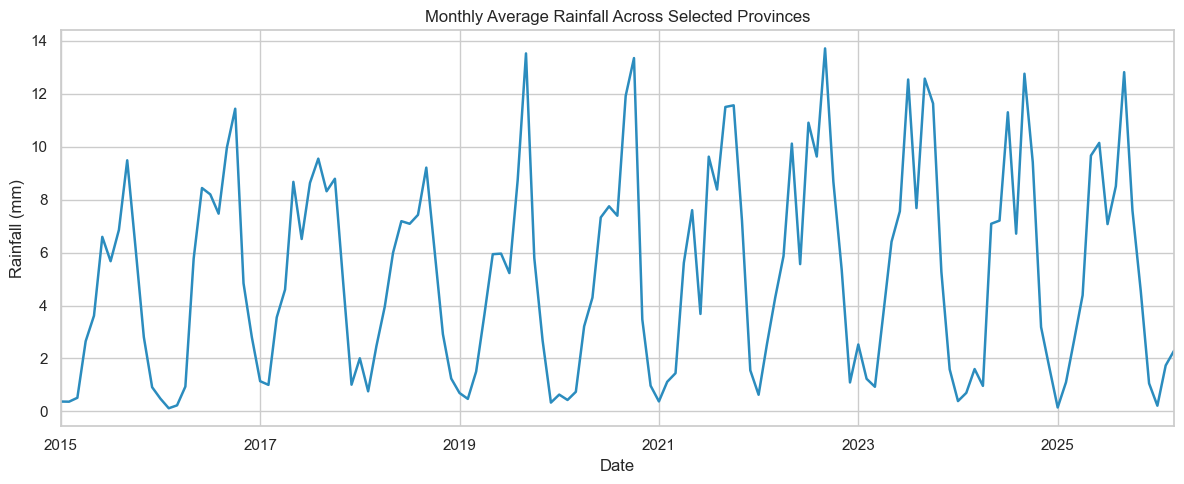

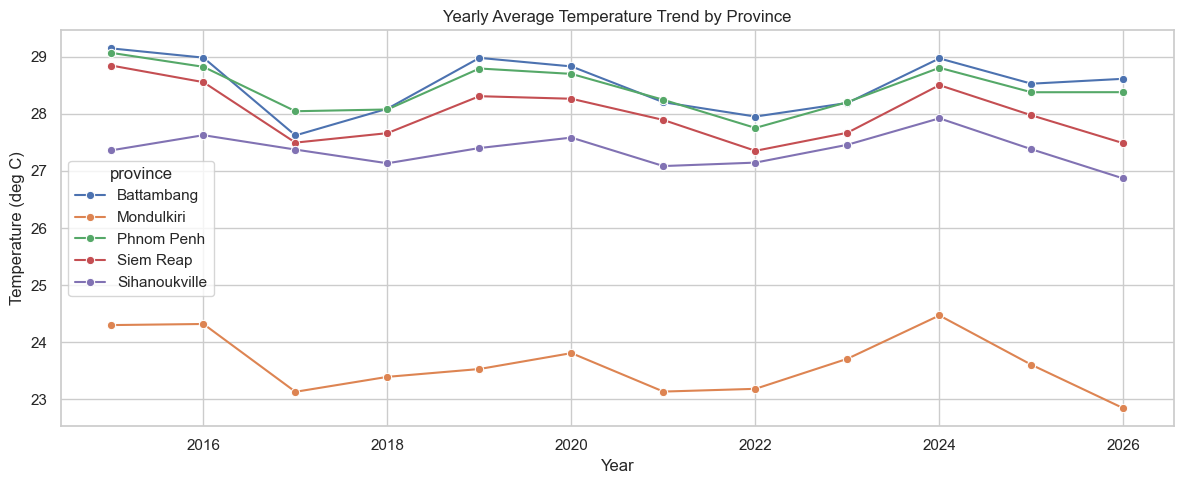

In [43]:
# Monthly rainfall trend
monthly_rain = df.set_index("date").resample("ME")["rain"].mean()

plt.figure(figsize=(12, 5))
monthly_rain.plot(color="#2b8cbe", linewidth=1.8)
plt.title("Monthly Average Rainfall Across Selected Provinces")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.tight_layout()
plt.show()

# Yearly average temperature trend by province
yearly_temp = (
    df.groupby(["year", "province"])["temp_avg"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 5))
sns.lineplot(data=yearly_temp, x="year", y="temp_avg", hue="province", marker="o")
plt.title("Yearly Average Temperature Trend by Province")
plt.xlabel("Year")
plt.ylabel("Temperature (deg C)")
plt.tight_layout()
plt.show()

In [45]:
# latest province snapshot for quick comparison
latest_snapshot = (
    df.sort_values("date")
    .groupby("province")
    .tail(1)
    [["province", "date", "temp_max", "temp_min", "temp_avg", "rain", "wind_speed"]]
    .reset_index(drop=True)
)
latest_snapshot

,province,date,temp_max,temp_min,temp_avg,rain,wind_speed
0,Siem Reap,2026-03-31,35.2,25.5,30.35,0.0,11.6
1,Mondulkiri,2026-03-31,30.4,20.4,25.40,0.9,17.5
2,Battambang,2026-03-31,38.2,26.6,32.40,0.0,13.1
3,Phnom Penh,2026-03-31,35.7,25.2,30.45,0.0,12.7
4,Sihanoukville,2026-03-31,31.3,25.1,28.20,0.0,12.0


### 3. EDA Summary
- The dataset is clean, chronologically consistent, and ready for model development.
- Temperature and rainfall patterns differ across provinces, showing distinct local climate behavior.
- Temporal plots reveal seasonal structure and gradual yearly variation, which are useful forecasting signals.
- Recommended next step: build province-level forecasting baselines (for example, Prophet or SARIMA) and compare MAE/RMSE.